In [1]:
import sympy as sp
from isb_lib import ISB
import matplotlib.pyplot as plt
import numpy as np

# Filtro pasa-bajos de primer orden en tiempo discreto

La ecuación en diferencias del filtro exponencial es

$$y[n]=\alpha x[n]+(1-\alpha)y[n-1], \qquad 0<\alpha<1.$$

Un valor pequeño de $\alpha$ suaviza más la señal y atenúa más las frecuencias altas; un valor cercano a 1 deja pasar una mayor parte de la señal. La función de transferencia es

$$H(z)=\frac{Y(z)}{X(z)}=\frac{\alpha}{1-(1-\alpha)z^{-1}}=\frac{\alpha z}{z-(1-\alpha)}.$$

El polo está en $z=1-\alpha$. Para $0<\alpha<1$ queda dentro del círculo unitario, por lo que el filtro causal es estable. El cero en el origen aparece al expresar la función de transferencia en potencias de $z$.

## Diseño de $\alpha$ para una frecuencia de corte digital

Se define $f_c$ como la frecuencia donde la magnitud cae 3.0103 dB respecto a la ganancia en continua. Para que ese corte coincida con el valor indicado, se calcula $\alpha$ usando la respuesta digital exacta:

$$\omega_c=2\pi\frac{f_c}{f_s}, \qquad q=1-\cos(\omega_c), \qquad \alpha=\sqrt{q^2+2q}-q.$$

Esta expresión requiere $0<f_c<f_s/2$. No es la aproximación analógica $\alpha=\frac{2\pi f_c/f_s}{1+2\pi f_c/f_s}$; con esa aproximación, el corte digital real no coincide exactamente con $f_c$.

In [2]:
z = sp.symbols("z")

fs = 1_000.0  # Frecuencia de muestreo (Hz)
fc = 100.0    # Frecuencia de corte deseada (Hz)
if not 0 < fc < fs / 2:
    raise ValueError("La frecuencia de corte debe estar entre 0 y Nyquist (fs/2).")

omega_c = 2 * np.pi * fc / fs
q = 1 - np.cos(omega_c)
alpha = np.sqrt(q**2 + 2 * q) - q

print(f"Frecuencia de muestreo: {fs:.1f} Hz")
print(f"Corte deseado: {fc:.1f} Hz")
print(f"Alpha: {alpha:.6f}")

Frecuencia de muestreo: 1000.0 Hz
Corte deseado: 100.0 Hz
Alpha: 0.455887


In [3]:
num = alpha * z
den = z - (1 - alpha)
H_z = num / den
sp.simplify(H_z)

0.455886780102867*z/(z - 0.544113219897133)

## Polos, ceros y respuesta en frecuencia

La respuesta se evalúa en $z=e^{j\omega}$ desde continua hasta Nyquist ($f_s/2$). La línea roja marca el corte digital diseñado; en ese punto la magnitud debe estar 3.0103 dB por debajo del nivel en continua.

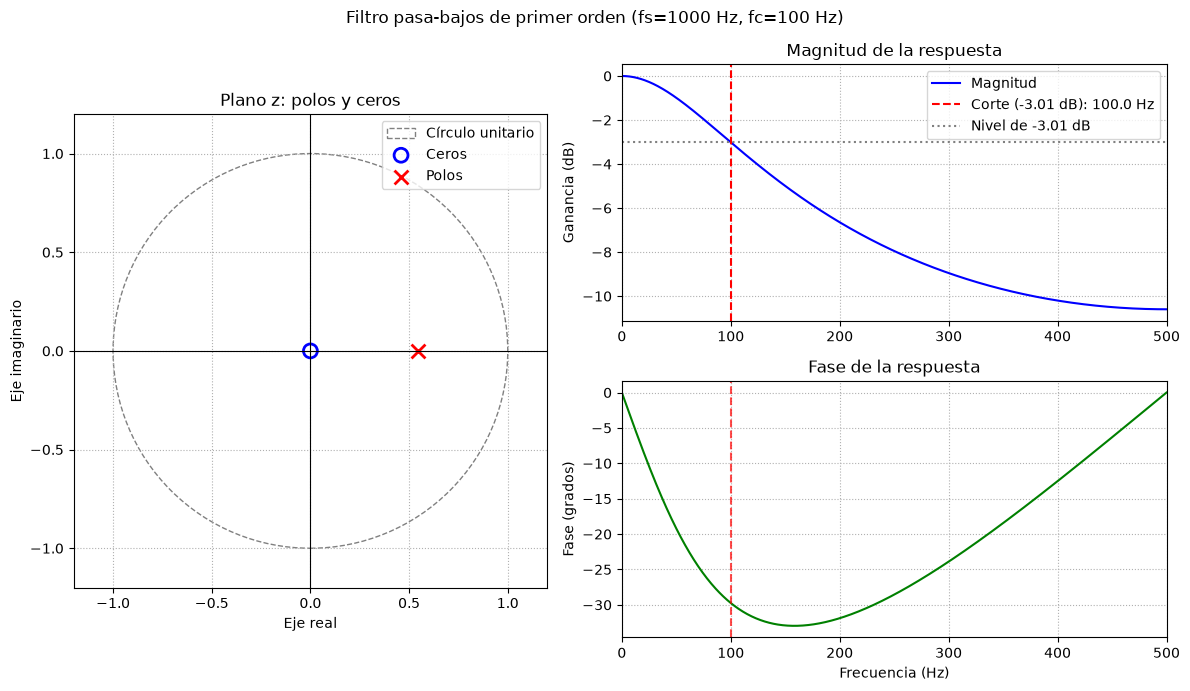

Corte calculado desde la respuesta: 100.00 Hz
Ganancia en continua: 0.00 dB
Ganancia en el corte: -3.01 dB


In [4]:
# Polos y ceros de H(z)
ceros = [complex(c.evalf()) for c in sp.solve(num, z)]
polos = [complex(p.evalf()) for p in sp.solve(den, z)]

# Respuesta en frecuencia: z = exp(j*omega)
omega = sp.symbols("omega", real=True)
H_w = H_z.subs(z, sp.exp(sp.I * omega))
H_func = sp.lambdify(omega, H_w, modules="numpy")

omega_vals = np.linspace(0, np.pi, 1_000)
freq_hz = omega_vals * fs / (2 * np.pi)
H_vals = H_func(omega_vals)
magnitud_db = 20 * np.log10(np.abs(H_vals))
fase_deg = np.rad2deg(np.unwrap(np.angle(H_vals)))
nivel_dc_db = magnitud_db[0]
nivel_corte_db = nivel_dc_db - 10 * np.log10(2)

# La fórmula exacta de alpha debe ubicar el cruce de -3.0103 dB en fc.
fc_3db = np.arccos(1 - alpha**2 / (2 * (1 - alpha))) * fs / (2 * np.pi)

fig = plt.figure(figsize=(12, 7))
grid = fig.add_gridspec(2, 2, width_ratios=(1, 1.15))
ax_pz = fig.add_subplot(grid[:, 0])
ax_mag = fig.add_subplot(grid[0, 1])
ax_phase = fig.add_subplot(grid[1, 1], sharex=ax_mag)

# Plano z
ax_pz.add_patch(plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--", label="Círculo unitario"))
ax_pz.axhline(0, color="black", linewidth=0.8)
ax_pz.axvline(0, color="black", linewidth=0.8)
ax_pz.scatter(np.real(ceros), np.imag(ceros), s=100, facecolors="none", edgecolors="blue", linewidths=2, label="Ceros")
ax_pz.scatter(np.real(polos), np.imag(polos), s=100, color="red", marker="x", linewidths=2, label="Polos")
ax_pz.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), title="Plano z: polos y ceros", xlabel="Eje real", ylabel="Eje imaginario")
ax_pz.set_aspect("equal")
ax_pz.grid(True, linestyle=":")
ax_pz.legend()

# Magnitud
ax_mag.plot(freq_hz, magnitud_db, color="blue", label="Magnitud")
ax_mag.axvline(fc_3db, color="red", linestyle="--", label=f"Corte (-3.01 dB): {fc_3db:.1f} Hz")
ax_mag.axhline(nivel_corte_db, color="gray", linestyle=":", label="Nivel de -3.01 dB")
ax_mag.set(title="Magnitud de la respuesta", ylabel="Ganancia (dB)")
ax_mag.grid(True, linestyle=":")
ax_mag.legend()

# Fase
ax_phase.plot(freq_hz, fase_deg, color="green")
ax_phase.axvline(fc_3db, color="red", linestyle="--", alpha=0.7)
ax_phase.set(title="Fase de la respuesta", xlabel="Frecuencia (Hz)", ylabel="Fase (grados)")
ax_phase.grid(True, linestyle=":")
ax_phase.set_xlim(0, fs / 2)

fig.suptitle(f"Filtro pasa-bajos de primer orden (fs={fs:.0f} Hz, fc={fc:.0f} Hz)")
fig.tight_layout()
plt.show()

print(f"Corte calculado desde la respuesta: {fc_3db:.2f} Hz")
print(f"Ganancia en continua: {nivel_dc_db:.2f} dB")
print(f"Ganancia en el corte: {np.interp(fc_3db, freq_hz, magnitud_db):.2f} dB")

### Interpretación

El polo queda dentro del círculo unitario, confirmando la estabilidad del filtro. La magnitud es cercana a 0 dB en bajas frecuencias y disminuye hacia Nyquist, como corresponde a un pasa-bajos. El corte indicado es el cruce de −3.0103 dB respecto a continua; la fase negativa en la banda de transición representa el desfase introducido por el filtro. Los gráficos se titulan «respuesta en frecuencia» porque el eje está en escala lineal, no logarítmica como en un diagrama de Bode clásico.